## Criteria for Resonance Capture and Stability

### <u>Adiabadicity criterion</u>

#### From Lin et al. (2025)

"Relatively slow migration is a necessary resonant capture condition. When the planets undergo fast convergent migration, they directly bypass the resonance before the eccentricities reach their equilibrium values."

For $j$:$j-1$ resonance, the resonance trapping criterion of slow migration for $q \ll 1$ is 
$$\tau_m > \frac{1}{n_1 ( 3(k-1))^{1/3}} \frac{1}{(\mu_2 \alpha f)^{4/3}}$$
where $\mu_i=m_i/M$ and $q=m_1/m_2$. Small $e$'s are assumed.

#### From Batygin & Morbidelli (2026)

In the limit of compact orbits, for $k$:$k-1$ resonance,
$$\frac{1}{\tau_a \Omega} \lesssim \frac{5\pi}{8}\left(\frac{5}{36k^5(k-1)^{2/3}}\right)^{1/3} \left(\frac{M}{m_1+m_2}\right)^{4/3}$$

### <u>Eccentricity criterion</u>

#### From Batygin & Morbidelli (2026)

Orbits must possess sufficiently low eccentricities, which is guaranteed due to $e$ damping in a protoplanetary disk.

### <u>Dissipative stability criterion</u>

#### From Batygin & Morbidelli (2026)

"In resonance, convergence migration excites $e$ while disk tides damp it, and long-lived trapping requires the existence of a fixed point in which these effects balance. As such, the resonant forcing must be sufficiently strong to offset $e$ damping... if $e$ damping is too strong relative to the resonant forcing, no stationary resonant equilibrium exists."

$$\frac{1}{\tau_a \Omega} \lesssim \frac{m_2}{M} \sqrt{\frac{32k^3 (1+\zeta) (\zeta \, \mathcal{K_1} + \mathcal{K_2})}{25\mathcal{K_1}\mathcal{K_2}}}$$
where $\mathcal{K_j} = \tau_a/\tau_{e_j}$

### <u>Overstability criterion</u>

#### From Deck & Batygin (2015)
For $m+1\text{:}m$ resonance, the condition for instability is (Eq. 15):
$$\epsilon_p < \epsilon_{p, \rm crit} \equiv \frac{3pm}{\mathcal{B}2^{3/2}} \frac{\tau_e}{\tau_{a,e}} \frac{(1+\zeta)^2}{\left(m(\zeta+1) + p\frac{\tau_e}{\tau_{a,e}}\right)}^{3/2} \left(\frac{\tau_e}{\tau_a}\right)^{3/2}$$

where 
$$\epsilon_p = \frac{m_1+m_2}{M}$$
$$\mathcal{B} \approx 0.8m$$
$$R\equiv \frac{|f|}{g-\delta_{m,2}\alpha_{\rm res}}$$
$$\alpha_{\rm res} = \frac{a_1}{a_2} = \left(\frac{k-1}{k}\right)^{2/3}$$
$$\tau_a = \left(\frac{1}{\tau_{a_2}} - \frac{1}{\tau_{a_1}} \right)^{-1}$$
$$\tau_e = \left(\frac{1}{\tau_{e_1}} + \frac{\zeta}{\tau_{e_2}} \right)^{-1}$$
$$\tau_{a,e} = \left(\frac{1}{\tau_{e_1}} - \frac{\zeta^2 \alpha_{\rm res}}{R^2 \tau_{e_2}} \right)^{-1}$$
$$\zeta = \frac{m_1}{m_2}$$

#### From Batygin & Morbidelli (2026)

For low values of $\mathcal{K}$, resonance locking gives way to the onset of overstability of resonant librations. The instability criterion is

$$\left[ \frac{\zeta (k(1+\zeta)-2\zeta)}{1-\zeta} \frac{\chi_a}{\chi_e}\right]^{3/2} < \frac{15}{32} \frac{1-\zeta^2}{M/m_2}\left(\frac{h}{r}\right)^3$$
where $h/r$ is the aspect ratio, $\chi_a = 1/(2.7+1.1s)$, $\chi_e = 1/0.780$. However, there may be a typo here where it should be $m_2/M$ instead of $M/m_2$.

### <u>Appendix: Damping timescales</u>

#### From Batygin & Morbidelli (2026)
$$\tau_{a_j} = \chi_a \left( \frac{m_j}{M} \frac{\Sigma a_j^2}{M} \left(\frac{h}{r}\right)^{-2} \Omega_j \right)^{-1}$$
$$\tau_{e_j} = \frac{\chi_e}{\chi_a} \left(\frac{h}{r}\right)^{2} \tau_{a_j}$$
where $h/r$ is the aspect ratio, $\chi_a = 1/(2.7+1.1s)$, $\chi_e = 1/0.780$.

### Plotting the above criteria

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
import astropy.units as u

def plot_prettier(dpi=200, fontsize=8, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

with open("fg_library.pkl", "rb") as f:
        fg_lib = pkl.load(f)

f, g = fg_lib[(3,2)]
print(f,g)

-0.9905647834003807 0.9059256135220133


-5.069411622485295
-4.822049003903532
-4.632768151866038
-4.479263850007095
-4.35009003483438


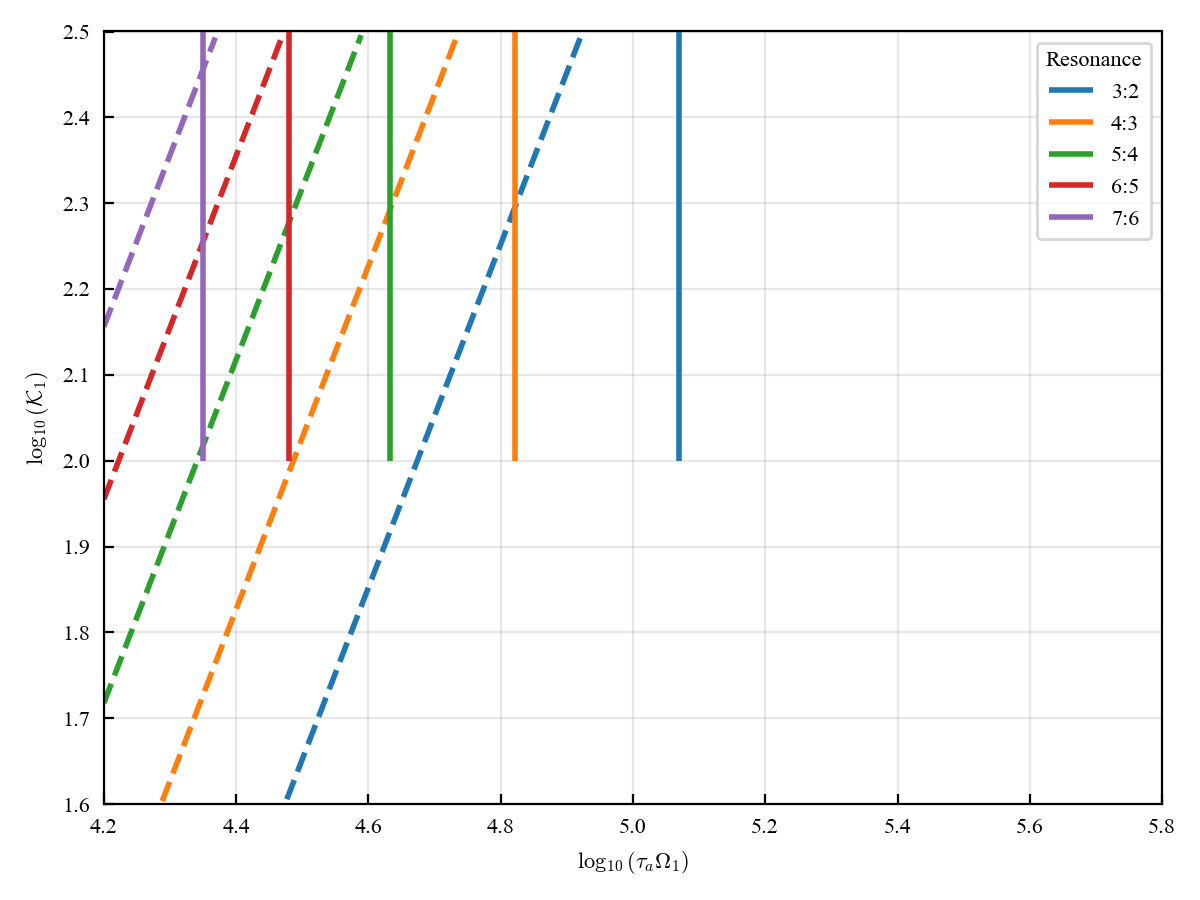

In [ ]:
m1 = 4 * m_earth
m2 = 8 * m_earth
M = 1.0

zeta = m1 / m2

def adiabadicity_crit(k):
    """1 / (tau_a Omega) <= C"""
    return (
        (5 * np.pi / 8)
        * (5 / (36 * k**5 * (k - 1)**(2/3)))**(1/3)
        * (M / (m1 + m2))**(4/3)
    )

def dissipative_crit(k, K1, K2):
    """1 / (tau_a Omega) = C"""
    return (
        (m2 / M)
        * np.sqrt(
            32 * k**3 * (1 + zeta) * (zeta*K1 + K2)
            / (25*K1*K2)
        )
    )

x_min, x_max = 4.2, 5.8
y_min, y_max = 0.5, 3.5

x = np.linspace(x_min, x_max, 400)

fig, ax = plt.subplots(figsize=(6, 4.5))

colors = [f"C{i}" for i in range(5)]

for k in range(3, 8):
    color = colors[k - 3]

    Ck = adiabadicity_crit(k)
    Bk = dissipative_crit(k, K1, K2)

    # Adiabaticity:
    # 1 / (tau_a Omega) <= Ck
    # tau_a Omega >= 1 / Ck
    # log10(tau_a Omega) >= -log10(Ck)
    x_ad = -np.log10(Ck)

    # Dissipative stability:
    # 1 / (tau_a Omega) <= Bk / sqrt(K1)
    # tau_a Omega >= sqrt(K1) / Bk
    # log10(K1) <= 2 * [log10(tau_a Omega) + log10(Bk)]
    #
    # Boundary:
    y_diss = 2 * (x + np.log10(Bk))

    # Intersection between adiabatic vertical line and dissipative line
    y_transition = 2 * (x_ad + np.log10(Bk))

    # Draw adiabatic vertical segment up to the transition
    # if y_transition > y_min:
    print(x_ad)
    ax.vlines(
        x=-x_ad,
        ymin=2,#y_min,
        ymax=2.5,#min(y_transition, y_max),
        lw=2,
        color=color,
        label=rf"{k}:{k-1}"
    )

    # Draw dissipative slanted segment above the transition
    mask = (x >= x_ad) & (y_diss >= y_transition) & (y_diss >= y_min) & (y_diss <= y_max)

    ax.plot(
        x[mask],
        y_diss[mask],
        lw=2,
        color=color,
        ls="--"
    )

    # Optional: mark transition point
    if y_min <= y_transition <= y_max:
        ax.plot(x_ad, y_transition, "o", color=color, ms=4)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel(r"$\log_{10}(\tau_a \Omega_1)$")
ax.set_ylabel(r"$\log_{10}(\mathcal{K}_1)$")

ax.legend(title="Resonance")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

%matplotlib widget

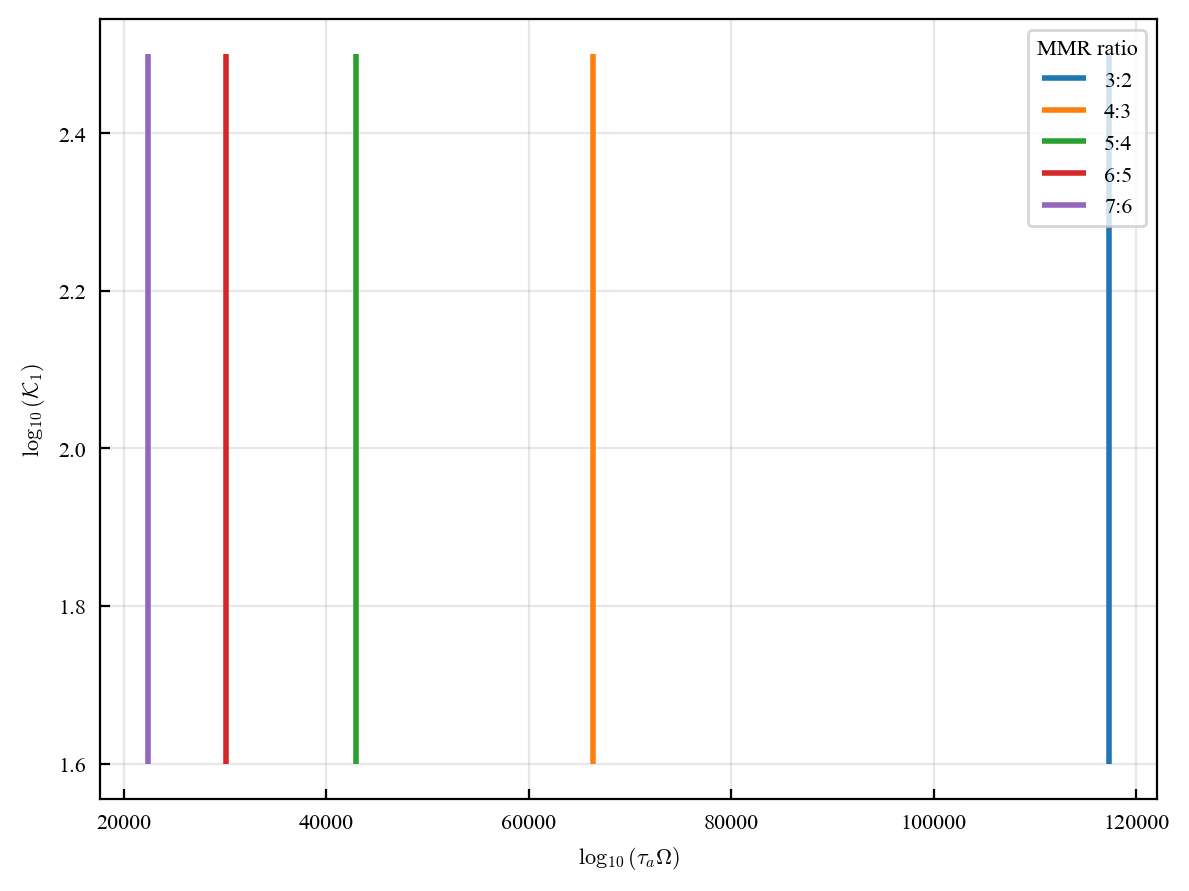

In [11]:
m1 = 4 * m_earth   # inner planet
m2 = 8 * m_earth   # outer planet
M = 1.0                       # star, solar masses

def criterion_C(k):
    """C_k in: 1 / (tau_a Omega) <= C_k"""
    return (
        (5 * np.pi / 8)
        * (5 / (36 * k**5 * (k - 1)**(2/3)))**(1/3)
        * (M / (m1 + m2))**(4/3)
    )

x = np.linspace(4.2, 5.8, 400)  # log10(tau_a Omega)

fig, ax = plt.subplots(figsize=(6, 4.5))

colors = [f"C{k}" for k in range(5)]

for k in range(3, 8):
    Ck = criterion_C(k)
    plt.vlines(x=Ck, ymin=1.6, ymax=2.5, lw=2, color=colors[k-3], label=rf"{k}:{k-1}") # y min y max are arbitrary
    
ax.set_xlabel(r"$\log_{10}(\tau_a \Omega)$")
ax.set_ylabel(r"$\log_{10}(\mathcal{K}_1)$")

ax.legend(title="MMR ratio")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()